# Figure 4 — Fluid-loading response

This notebook evaluates the linearity of the coupled liquid-flux response under macroscopic pressure-gradient loading applied along the $x$- and $y$-directions.

---

**Authors**

Haotian XIAO
Martin GENET

École Polytechnique, Palaiseau, France


## Imports

In [1]:
from pathlib import Path
import math
import sys

import dolfin
import myPythonLibrary as mypy
import dolfin_mech as dmech

## Project paths

In [2]:
def find_project_dir():
    current_dir = Path.cwd().resolve()

    for candidate in (current_dir, *current_dir.parents):
        if (
            (candidate / "demos").is_dir()
            and (candidate / "src").is_dir()
            and (candidate / "environment.yml").is_file()
        ):
            return candidate

    raise RuntimeError("Could not locate the project directory.")


PROJECT_DIR = find_project_dir()
SRC_DIR = PROJECT_DIR / "src"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src
RESULTS_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/results


## Fluid-loading function

In [3]:
def run_gradp_linearity_test(
    res_folder,
    r0_list=(0.2,),
    probe_list=("gx", "gy"),
    gradp_max=0.05,
    perform_tests=0,
):
    res_folder = Path(res_folder)
    res_folder.mkdir(parents=True, exist_ok=True)

    test = mypy.Test(
        res_folder=str(res_folder),
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    material_parameters = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1.0,
        "eta": 1e-5,
    }

    dim = 2
    n_steps = 1
    pf = 0.0

    def run_one_probe(r0, probe):
        if probe == "gx":
            gx_ini_lst = [0.0]
            gx_fin_lst = [gradp_max]
            gy_ini_lst = [0.0]
            gy_fin_lst = [0.0]

        elif probe == "gy":
            gx_ini_lst = [0.0]
            gx_fin_lst = [0.0]
            gy_ini_lst = [0.0]
            gy_fin_lst = [gradp_max]

        else:
            raise ValueError("probe must be 'gx' or 'gy'")

        res_basename = f"gradp-linearity-r0={r0}-pf={pf}-{probe}"
        result_basename = res_folder / res_basename
        mesh_filebasename = res_folder / f"mesh-gradp-r0={r0}"

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"][f"sigma_bar_{i}{j}"] = 0.0

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst
        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        load_params["air"]["pf"] = pf
        load_params["air"]["pf_lst"] = [pf] * n_steps

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3.0) / 2.0,
                "xmax": 1.0,
                "ymax": math.sqrt(3.0) / 2.0,
                "r0": r0,
                "l": 0.03,
                "hole_shape": "hex",
                "add_center_hole": True,
                "mesh_filebasename": str(mesh_filebasename),
            },
            mat_params={
                "skel": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "bulk": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "pore": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1e-6, 0.0),
                        (0.0, 1e-6),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs="pbc",
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1.0],
                "dt_ini_lst": [1e-3],
                "dt_min_lst": [1e-6],
                "dt_max_lst": [5e-3],
            },
            load_params=load_params,
            res_basename=str(result_basename),
            verbose=0,
        )

        test.test(str(result_basename))

    for r0 in r0_list:
        for probe in probe_list:
            print(
                f"Running r0={r0}, "
                f"probe={probe}, "
                f"gradp_max={gradp_max}"
            )

            run_one_probe(
                r0=r0,
                probe=probe,
            )

    return res_folder

## Simulation parameters

In [4]:
r0_list = (0.315, 0.41)
probe_list = ("gx", "gy")
gradp_max = 1.3

res_folder = RESULTS_DIR / "Figure4_gradp_linearity"

## Numerical simulations

In [5]:
res_folder = run_gradp_linearity_test( res_folder=res_folder, r0_list=r0_list, probe_list=probe_list, gradp_max=gradp_max, perform_tests=0, )

Running r0=0.315, probe=gx, gradp_max=1.3
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy 

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running r0=0.315, probe=gy, gradp_max=1.3
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy 

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running r0=0.41, probe=gy, gradp_max=1.3
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy o

## Post-processing

2026-06-25 21:32:54.705 ( 918.248s) [          7DB47A]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x11e099ab0): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-25 21:32:54.705 ( 918.248s) [          7DB47A]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x11e099ab0): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-25 21:32:54.705 ( 918.248s) [          7DB47A]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x11e099ab0): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-25 21:32:54.705 ( 918.248s) [          7DB47A]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x11e099ab0): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-25 21:32:54.705 ( 918.248s) [          7DB47A]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x11e099ab0): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-25 21:32:54.705 ( 918.248s) [          7DB47A]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x11e099ab0): Unsupported cell type: 56 Sett

r0 = 0.315
phi = 0.2976749999999997
r0 = 0.41
phi = 0.5043000000000002


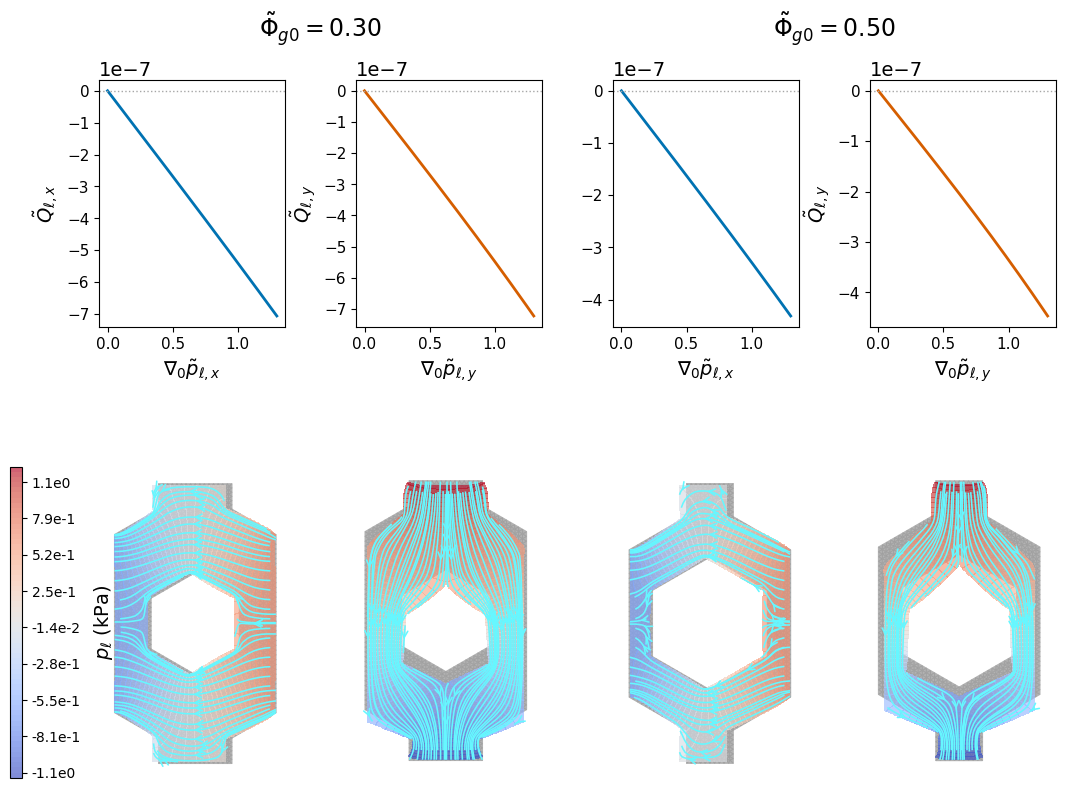

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure4_q_vs_gradp.pdf
Figure saved in: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure4_q_vs_gradp.pdf


In [6]:
from Plot_Microporoflow import plot_q_vs_gradp

figures_folder = RESULTS_DIR / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

figure_path = figures_folder / "Figure4_q_vs_gradp.pdf"

results = plot_q_vs_gradp(
    res_folder=str(res_folder),
    res_basename_prefix="gradp-linearity",
    r0_list=r0_list,
    pf=0.0,
    slice_start=0,
    save_name=str(figure_path),
    show_plot=True,
)

print("Figure saved in:", figure_path)
